# Credit Risk & Loan Default Analysis

**Business objective:** Identify where default risk is concentrated across borrower and loan characteristics, then compare three classification models — Logistic Regression, Random Forest and XGBoost — for identifying higher-risk loans.

**Analysis approach:** Start with portfolio KPIs and focused EDA across credit grade, purpose, income, DTI, interest rate and term. Then use the same feature set and the same stratified train/test split for all models so performance is directly comparable.

**Model evaluation:** Compare Accuracy, Precision, Recall, F1-score and ROC-AUC, with particular attention to default-class Recall and ROC-AUC.


## 1. Import libraries

In [2]:
import sys
print(sys.executable)

C:\Users\anany\anaconda\python.exe


In [3]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score)
from xgboost import XGBClassifier

## 2. Load and check 100,000 loan records

In [2]:
loan_data = pd.read_csv(
    r"C:\temp\credit risk loan default_updated data.csv",
    nrows=100000
)

print("Rows and columns:", loan_data.shape)
print("Total missing values:", loan_data.isnull().sum().sum())

display(loan_data.head())

Rows and columns: (100000, 26)
Total missing values: 7377


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,purpose,issue_d,loan_status,...,dti,revol_bal,revol_util,open_acc,total_acc,pub_rec,delinq_2yrs,inq_last_6mths,earliest_cr_line,Income Band
0,30000,30000,36 months,22.35,1151.16,D,D5,debt_consolidation,Dec-18,Fully Paid,...,30.46,15603,37.0,11,19,1,0,0,Jan-12,High
1,40000,40000,60 months,16.14,975.71,C,C4,credit_card,Dec-18,Fully Paid,...,50.53,34971,64.5,18,37,0,0,0,Jun-09,Low
2,20000,20000,36 months,7.56,622.68,A,A3,credit_card,Dec-18,Fully Paid,...,18.92,25416,29.9,9,19,0,0,0,Feb-99,High
3,4500,4500,36 months,11.31,147.99,B,B3,credit_card,Dec-18,Fully Paid,...,4.64,4472,15.3,12,25,0,0,0,Dec-03,Low
4,8425,8425,36 months,27.27,345.18,E,E5,credit_card,Dec-18,Fully Paid,...,12.37,36812,65.7,21,37,0,0,0,Oct-97,High


## 3. Clean only the columns needed for analysis

In [3]:
credit_portfolio = loan_data.copy()

# Ensure important fields are numeric
numeric_columns_to_clean = ["int_rate", "annual_inc", "loan_amnt", "dti"]

for column_name in numeric_columns_to_clean:
    credit_portfolio[column_name] = pd.to_numeric(
        credit_portfolio[column_name]
        .astype(str)
        .str.replace("%", "", regex=False),
        errors="coerce"
    )

## 4. Keep loans with a known final outcome

`Fully Paid` = non-default.  
`Charged Off` or `Default` = default.

Current/late loans are excluded because their final outcome is not yet known.

In [4]:
completed_loan_statuses = ["Fully Paid", "Charged Off", "Default"]

credit_portfolio = credit_portfolio[
    credit_portfolio["loan_status"].isin(completed_loan_statuses)
].copy()

credit_portfolio["default_flag"] = (
    credit_portfolio["loan_status"]
    .isin(["Charged Off", "Default"])
    .astype(int)
)

print(credit_portfolio[["loan_status", "default_flag"]].value_counts())

loan_status  default_flag
Fully Paid   0               79178
Charged Off  1               20812
Default      1                  10
Name: count, dtype: int64


## 5. Portfolio KPIs

In [5]:
portfolio_loans = len(credit_portfolio)
portfolio_amount = credit_portfolio["loan_amnt"].sum()
average_loan_amount = credit_portfolio["loan_amnt"].mean()
portfolio_default_rate = credit_portfolio["default_flag"].mean()

print("Total loans:", f"{portfolio_loans:,}")
print("Total loan amount:", f"${portfolio_amount:,.0f}")
print("Average loan amount:", f"${average_loan_amount:,.2f}")
print("Default rate:", f"{portfolio_default_rate:.2%}")

Total loans: 100,000
Total loan amount: $1,450,490,400
Average loan amount: $14,504.90
Default rate: 20.82%


## 6. Credit-risk exploratory analysis (EDA)

Before building prediction models, analyse **where default risk is concentrated in the portfolio**. The EDA focuses on six decision-relevant dimensions used in this project:

- credit grade,
- loan purpose,
- annual income,
- debt-to-income ratio (DTI),
- interest rate,
- and loan term.

For every segment, both **loan count** and **default rate** are shown. Loan count matters because a very high default rate in a tiny segment may be less important than a moderately high rate in a large segment.

**Important:** These are descriptive associations in this dataset. They do not by themselves prove that a variable causes default.


In [6]:
# Reusable summary function for categorical/banded EDA

def default_risk_summary(data, group_column):
    summary = (
        data.groupby(group_column, observed=False)
        .agg(
            Total_Loans=("default_flag", "size"),
            Defaults=("default_flag", "sum"),
            Default_Rate=("default_flag", "mean")
        )
        .reset_index()
    )
    summary["Default_Rate"] = summary["Default_Rate"] * 100
    return summary


def print_risk_extremes(summary, label_column, minimum_loans=50):
    eligible = summary[summary["Total_Loans"] >= minimum_loans].dropna(subset=["Default_Rate"])
    if len(eligible) >= 2:
        highest = eligible.loc[eligible["Default_Rate"].idxmax()]
        lowest = eligible.loc[eligible["Default_Rate"].idxmin()]
        print(
            f"Highest observed default rate: {highest[label_column]} "
            f"({highest['Default_Rate']:.2f}%, n={int(highest['Total_Loans']):,})"
        )
        print(
            f"Lowest observed default rate: {lowest[label_column]} "
            f"({lowest['Default_Rate']:.2f}%, n={int(lowest['Total_Loans']):,})"
        )


### 6.1 Default risk by credit grade

Credit grade is a direct credit-quality indicator. This view checks whether observed default rates increase as grades become weaker.


,grade,Total_Loans,Defaults,Default_Rate
0,A,16183,984,6.08
1,B,29504,4436,15.04
2,C,29417,6847,23.28
3,D,16516,5078,30.75
4,E,5880,2214,37.65
5,F,1992,983,49.35
6,G,508,280,55.12


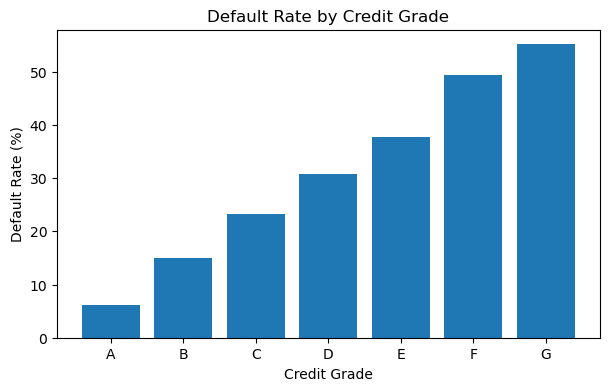

Highest observed default rate: G (55.12%, n=508)
Lowest observed default rate: A (6.08%, n=16,183)


In [7]:
grade_risk_summary = default_risk_summary(credit_portfolio, "grade").sort_values("grade")
display(grade_risk_summary.round(2))

plt.figure(figsize=(7, 4))
plt.bar(grade_risk_summary["grade"].astype(str), grade_risk_summary["Default_Rate"])
plt.title("Default Rate by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Default Rate (%)")
plt.show()

print_risk_extremes(grade_risk_summary, "grade")


### 6.2 Default risk by loan purpose

Loan purpose can reveal whether certain uses of credit are associated with higher observed repayment risk. Very small-purpose categories should be interpreted cautiously.


,purpose,Total_Loans,Defaults,Default_Rate
10,small_business,1069,371,34.71
12,wedding,3,1,33.33
6,medical,1543,374,24.24
7,moving,919,210,22.85
2,debt_consolidation,55303,12234,22.12
8,other,8296,1775,21.40
5,major_purchase,2831,581,20.52
9,renewable_energy,66,13,19.70
4,house,1148,225,19.60
11,vacation,899,168,18.69


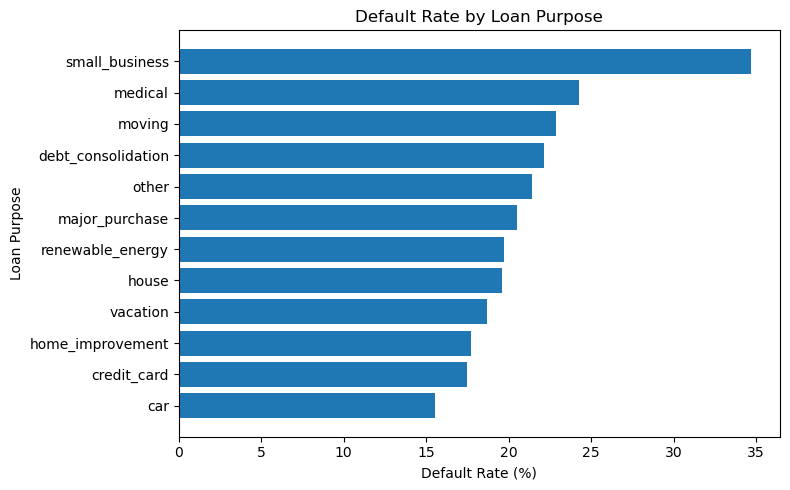

Highest observed default rate: small_business (34.71%, n=1,069)
Lowest observed default rate: car (15.56%, n=1,337)


In [8]:
purpose_risk_summary = default_risk_summary(credit_portfolio, "purpose")
purpose_risk_summary = purpose_risk_summary.sort_values("Default_Rate", ascending=False)
display(purpose_risk_summary.round(2))

# Plot only categories with a reasonable number of observations to avoid over-emphasising tiny groups
purpose_plot = purpose_risk_summary[purpose_risk_summary["Total_Loans"] >= 50].copy()
purpose_plot = purpose_plot.sort_values("Default_Rate", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(purpose_plot["purpose"].astype(str), purpose_plot["Default_Rate"])
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()

print_risk_extremes(purpose_risk_summary, "purpose")


### 6.3 Default risk by annual-income band

Annual income is used as a simple proxy for repayment capacity. Income is grouped into broad bands so the pattern is easier to interpret than a raw-income scatter plot.


,income_band,Total_Loans,Defaults,Default_Rate
0,< $40k,17186,4436,25.81
1,$40k-$60k,26399,5952,22.55
2,$60k-$80k,21913,4434,20.23
3,$80k-$100k,14352,2745,19.13
4,$100k+,20150,3255,16.15


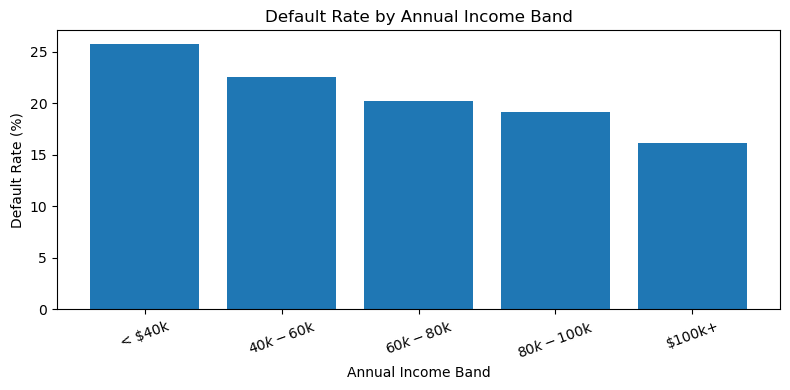

Highest observed default rate: < $40k (25.81%, n=17,186)
Lowest observed default rate: $100k+ (16.15%, n=20,150)


In [9]:
income_bins = [-float("inf"), 40000, 60000, 80000, 100000, float("inf")]
income_labels = ["< $40k", "$40k-$60k", "$60k-$80k", "$80k-$100k", "$100k+"]

credit_portfolio["income_band"] = pd.cut(
    credit_portfolio["annual_inc"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

income_risk_summary = default_risk_summary(credit_portfolio, "income_band")
display(income_risk_summary.round(2))

plt.figure(figsize=(8, 4))
plt.bar(income_risk_summary["income_band"].astype(str), income_risk_summary["Default_Rate"])
plt.title("Default Rate by Annual Income Band")
plt.xlabel("Annual Income Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print_risk_extremes(income_risk_summary, "income_band")


### 6.4 Default risk by DTI band

DTI (debt-to-income ratio) measures debt burden relative to income. Higher DTI can indicate less financial capacity to absorb additional repayment obligations.


,dti_band,Total_Loans,Defaults,Default_Rate
0,<10,21047,3553,16.88
1,10-20,40644,7671,18.87
2,20-30,28737,7009,24.39
3,30-40,8215,2327,28.33
4,40+,1242,244,19.65


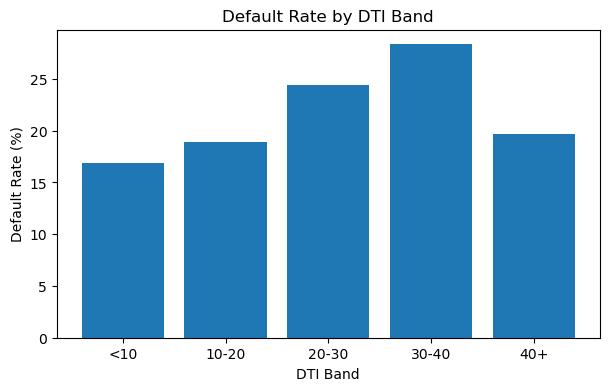

Highest observed default rate: 30-40 (28.33%, n=8,215)
Lowest observed default rate: <10 (16.88%, n=21,047)


In [10]:
dti_bins = [-float("inf"), 10, 20, 30, 40, float("inf")]
dti_labels = ["<10", "10-20", "20-30", "30-40", "40+"]

credit_portfolio["dti_band"] = pd.cut(
    credit_portfolio["dti"],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True,
    right=False
)

dti_risk_summary = default_risk_summary(credit_portfolio, "dti_band")
display(dti_risk_summary.round(2))

plt.figure(figsize=(7, 4))
plt.bar(dti_risk_summary["dti_band"].astype(str), dti_risk_summary["Default_Rate"])
plt.title("Default Rate by DTI Band")
plt.xlabel("DTI Band")
plt.ylabel("Default Rate (%)")
plt.show()

print_risk_extremes(dti_risk_summary, "dti_band")


### 6.5 Default risk by interest-rate band

Interest rates often reflect lender-assessed risk as well as loan pricing. This analysis therefore shows an **association**, not proof that a higher interest rate itself causes default.


,interest_rate_band,Total_Loans,Defaults,Default_Rate
0,<10%,25300,2173,8.59
1,10-15%,41193,8102,19.67
2,15-20%,20900,5805,27.78
3,20-25%,8293,2866,34.56
4,25%+,4314,1876,43.49


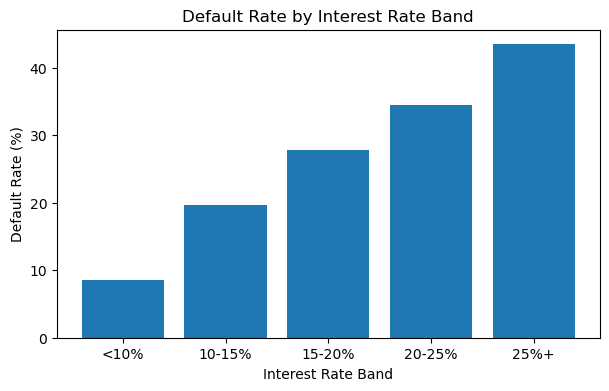

Highest observed default rate: 25%+ (43.49%, n=4,314)
Lowest observed default rate: <10% (8.59%, n=25,300)


In [11]:
interest_bins = [-float("inf"), 10, 15, 20, 25, float("inf")]
interest_labels = ["<10%", "10-15%", "15-20%", "20-25%", "25%+"]

credit_portfolio["interest_rate_band"] = pd.cut(
    credit_portfolio["int_rate"],
    bins=interest_bins,
    labels=interest_labels,
    include_lowest=True,
    right=False
)

interest_risk_summary = default_risk_summary(credit_portfolio, "interest_rate_band")
display(interest_risk_summary.round(2))

plt.figure(figsize=(7, 4))
plt.bar(interest_risk_summary["interest_rate_band"].astype(str), interest_risk_summary["Default_Rate"])
plt.title("Default Rate by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Default Rate (%)")
plt.show()

print_risk_extremes(interest_risk_summary, "interest_rate_band")


### 6.6 Default risk by loan term

This comparison tests whether longer-duration loans show a different observed default rate from shorter-duration loans.


,term,Total_Loans,Defaults,Default_Rate
0,36 months,75229,13733,18.25
1,60 months,24771,7089,28.62


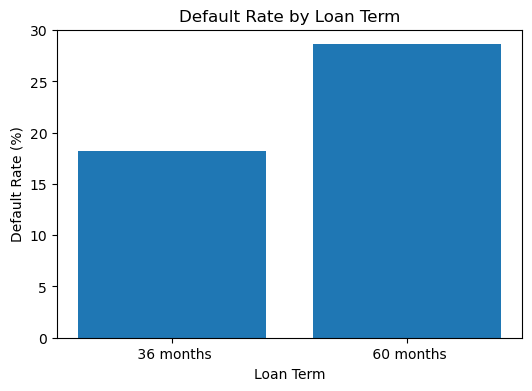

Highest observed default rate:  60 months (28.62%, n=24,771)
Lowest observed default rate:  36 months (18.25%, n=75,229)


In [12]:
term_risk_summary = default_risk_summary(credit_portfolio, "term")
term_risk_summary = term_risk_summary.sort_values("term")
display(term_risk_summary.round(2))

plt.figure(figsize=(6, 4))
plt.bar(term_risk_summary["term"].astype(str), term_risk_summary["Default_Rate"])
plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")
plt.show()

print_risk_extremes(term_risk_summary, "term")


### 6.7 EDA findings summary

Use the outputs above to state the **actual observed findings**. A good interview summary should answer:

1. Which credit grade had the highest and lowest observed default rate?
2. Which major loan purposes were relatively riskier?
3. How did default risk change across income bands?
4. Did higher DTI bands show higher default risk?
5. How strongly did default rate vary across interest-rate bands?
6. Was default risk different between the available loan terms?

Do not claim causality from these charts. They describe how default risk is distributed across the analysed portfolio and motivate the multivariable modelling that follows.


## 7. Select model features

The feature set matches the original project: loan amount, interest rate, income, DTI, term, grade, purpose, home ownership and verification status.

In [13]:
default_model_columns = [
    "loan_amnt", "int_rate", "annual_inc", "dti",
    "term", "grade", "purpose",
    "home_ownership", "verification_status"
]

loan_features = credit_portfolio[default_model_columns]
default_target = credit_portfolio["default_flag"]

train_features, test_features, train_target, test_target = train_test_split(
    loan_features,
    default_target,
    test_size=0.20,
    random_state=42,
    stratify=default_target
)

print("Training rows:", len(train_features))
print("Testing rows:", len(test_features))

Training rows: 80000
Testing rows: 20000


## 8. Preprocessing

This preprocessing is necessary rather than decorative:
- `dti` contains some missing values, so numeric fields use median imputation.
- categorical fields use the most frequent value if missing.
- text categories are one-hot encoded.
- numerical fields are scaled. Scaling is especially useful for Logistic Regression; using the same transformed feature matrix across models keeps the workflow consistent.


In [14]:
numeric_default_columns = ["loan_amnt", "int_rate", "annual_inc", "dti"]
categorical_default_columns = [
    "term", "grade", "purpose",
    "home_ownership", "verification_status"
]

numeric_preparation = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_preparation = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

default_model_preprocessing = ColumnTransformer([
    ("numeric", numeric_preparation, numeric_default_columns),
    ("category", categorical_preparation, categorical_default_columns)
])

## 9. Logistic Regression

In [15]:
logistic_default_model = Pipeline([
    ("preprocessing", default_model_preprocessing),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logistic_default_model.fit(train_features, train_target)

logistic_predictions = logistic_default_model.predict(test_features)
logistic_probabilities = logistic_default_model.predict_proba(test_features)[:, 1]

## 10. Random Forest

In [16]:
random_forest_default_model = Pipeline([
    ("preprocessing", default_model_preprocessing),
    ("model", RandomForestClassifier(
        n_estimators=25,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1
    ))
])

random_forest_default_model.fit(train_features, train_target)

forest_predictions = random_forest_default_model.predict(test_features)
forest_probabilities = random_forest_default_model.predict_proba(test_features)[:, 1]

## 11. XGBoost

XGBoost is added as a third model because Random Forest showed only a marginal improvement over Logistic Regression. Boosting builds trees sequentially, with later trees focusing more on errors made by earlier trees.

`scale_pos_weight` is calculated from the training data to account for class imbalance without changing the train/test split.


In [17]:
# Weight the minority default class using only the training data
non_default_count = (train_target == 0).sum()
default_count = (train_target == 1).sum()
scale_pos_weight_value = non_default_count / default_count

print("XGBoost scale_pos_weight:", round(scale_pos_weight_value, 3))

xgboost_default_model = Pipeline([
    ("preprocessing", default_model_preprocessing),
    ("model", XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight_value,
        random_state=42,
        n_jobs=1
    ))
])

xgboost_default_model.fit(train_features, train_target)

xgboost_predictions = xgboost_default_model.predict(test_features)
xgboost_probabilities = xgboost_default_model.predict_proba(test_features)[:, 1]


XGBoost scale_pos_weight: 3.802


## 12. Compare all three models

All three models use the same features and the same test set. For credit risk, do not rely on accuracy alone: default-class Recall shows how many actual defaulters are identified, while ROC-AUC measures overall ranking/discrimination ability.


In [18]:
default_model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(test_target, logistic_predictions),
        accuracy_score(test_target, forest_predictions),
        accuracy_score(test_target, xgboost_predictions)
    ],
    "Precision": [
        precision_score(test_target, logistic_predictions),
        precision_score(test_target, forest_predictions),
        precision_score(test_target, xgboost_predictions)
    ],
    "Recall": [
        recall_score(test_target, logistic_predictions),
        recall_score(test_target, forest_predictions),
        recall_score(test_target, xgboost_predictions)
    ],
    "F1_Score": [
        f1_score(test_target, logistic_predictions),
        f1_score(test_target, forest_predictions),
        f1_score(test_target, xgboost_predictions)
    ],
    "ROC_AUC": [
        roc_auc_score(test_target, logistic_probabilities),
        roc_auc_score(test_target, forest_probabilities),
        roc_auc_score(test_target, xgboost_probabilities)
    ]
})

display(default_model_results.round(3).sort_values("ROC_AUC", ascending=False))


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
2,XGBoost,0.629,0.319,0.689,0.436,0.709
1,Random Forest,0.624,0.312,0.669,0.426,0.699
0,Logistic Regression,0.621,0.309,0.663,0.422,0.691


### How to interpret the result

- If XGBoost clearly improves ROC-AUC and/or default Recall, keep it as the strongest predictive model.
- If XGBoost improves only marginally, report that honestly; the simpler Logistic Regression may remain attractive because it is easier to interpret.
- A model should not be selected only because it has the highest Accuracy. In default prediction, missing a true defaulter can be more important than a small change in overall Accuracy.


## 13. Random Forest feature importance


,Feature,Importance
1,int rate,0.268023
6,grade A,0.186737
7,grade B,0.052967
0,loan amnt,0.052114
27,home ownership MORTGAGE,0.050825
3,dti,0.050771
2,annual inc,0.038131
5,term 60 months,0.037488
31,verification status Verified,0.035489
30,verification status Not Verified,0.035258


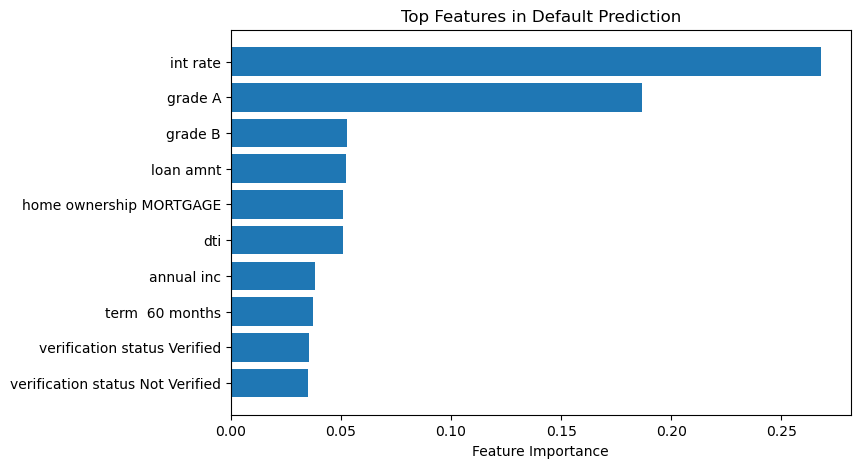

In [19]:
transformed_feature_names = (
    random_forest_default_model
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

feature_importance_table = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": random_forest_default_model.named_steps["model"].feature_importances_
})

feature_importance_table["Feature"] = (
    feature_importance_table["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("category__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_default_features = (
    feature_importance_table
    .sort_values("Importance", ascending=False)
    .head(10)
)

display(top_default_features)

plt.figure(figsize=(8, 5))
plt.barh(
    top_default_features["Feature"][::-1],
    top_default_features["Importance"][::-1]
)
plt.title("Top Features in Default Prediction")
plt.xlabel("Feature Importance")
plt.show()

## 14. Business conclusions

Build the final project conclusion from **two layers of evidence**:

### Portfolio / EDA findings
Report the actual patterns observed across:
- credit grade,
- loan purpose,
- annual-income band,
- DTI band,
- interest-rate band,
- and loan term.

Highlight both **default rate and segment size** so that a tiny high-risk category is not over-interpreted.

### Predictive-model findings
Compare Logistic Regression, Random Forest and XGBoost using:
- ROC-AUC,
- default-class Recall,
- Precision,
- F1-score,
- and Accuracy.

For credit-risk screening, give particular attention to **Recall**, because a false negative means an actual defaulter is classified as non-default. However, Precision also matters because flagging too many good borrowers can create unnecessary rejection or review costs.

**Interview-ready storyline:**

> “I first measured the overall portfolio default rate and segmented risk by credit grade, loan purpose, income, DTI, interest rate and loan term. This showed where defaults were concentrated and which borrower or loan characteristics were associated with higher observed risk. I then moved from descriptive analysis to prediction, using Logistic Regression as an interpretable baseline, Random Forest to capture nonlinear relationships, and XGBoost to test whether boosting added predictive value. I compared the models using ROC-AUC, Recall, Precision and F1-score rather than relying only on Accuracy, and selected the final model based on the actual trade-off between identifying defaulters and avoiding excessive false positives.”

**Caution:** EDA and feature importance show associations within this dataset; they should not be presented as proof that a variable causes default.
